In [1]:
import numpy as np
import os
import physionet_challenge_utility_script as pc

In [2]:
gender, age, labels, ecg_filenames = pc.import_key_data("data/") #loads all ECG images in data
#labels has Dx
ecg_filenames = np.asarray(ecg_filenames)
print(ecg_filenames)
print(len(ecg_filenames))

['data/\\00000.png' 'data/\\00001.png' 'data/\\00002.png' ...
 'data/\\21796.png' 'data/\\21797.png' 'data/\\21798.png']


In [4]:
import pandas as pd
SNOMED_scored=pd.read_csv("SNOMED_mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored=pd.read_csv("SNOMED_mappings/SNOMED_mappings_unscored.csv", sep=";")
df_labels = pc.make_undefined_class(labels,SNOMED_unscored)
df_labels #one row for each sample, each row is comma separate list of class labels (Dx)

,0
0,"251146004,426783006"
1,"undefined class,undefined class,undefined clas..."
2,"undefined class,426783006"
3,426783006
4,426783006
...,...
21794,426783006
21795,"426783006,undefined class"
21796,426783006
21797,"164934002,426783006,undefined class"


In [5]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '251146004' '270492004' '284470004' '39732003'
 '426177001' '426783006' '427084000' '427393009' '445118002' '47665007'
 '59118001' '59931005' '63593006' '698252002' '713426002'
 'undefined class']
classes: 23


In [7]:
'''
They are making some class lables into 'undefined' then when they perform onehot encoding
they remove the undefined class such that 'undefined' samples have label with all 0s.

This is an example of multi-label classification, the model outputs M-1 binary classifications.
It which should involve sigmoid activation and BCE loss. 
'''
#y[2] is undefined class,426783006 
#y[3] and y[4] is 426783006
#y[2], y[3], y[4] have same one hot encoding vector

#y[21796] is 426783006                            --> [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
#y[21797] is 164934002,426783006,undefined class  --> [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
#y[21798] is undefined class,164934002,426783006  --> [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
print(len(snomed_classes))
print(len(y))

23
21799


In [8]:
import copy
y = copy.deepcopy(y.transpose())

common = []
index = []
for i in range(len(snomed_classes)):
    # if snomed_classes[i] in ['atrial fibrillation','left bundle branch block','1st degree av block','premature atrial contraction','sinus rhythm','complete right bundle branch block']:
    ##only keeping these 6 classes
    if snomed_classes[i] in ['164889003', '164909002', '270492004', '284470004', '426783006', '59118001']:
        common.append(y[i])
    else:
        index.append(i)

snomed_classes = np.delete(snomed_classes, index)
temp = np.array(common)
y = copy.deepcopy(temp.transpose()) 


In [9]:
np.shape(y)

(21799, 6)

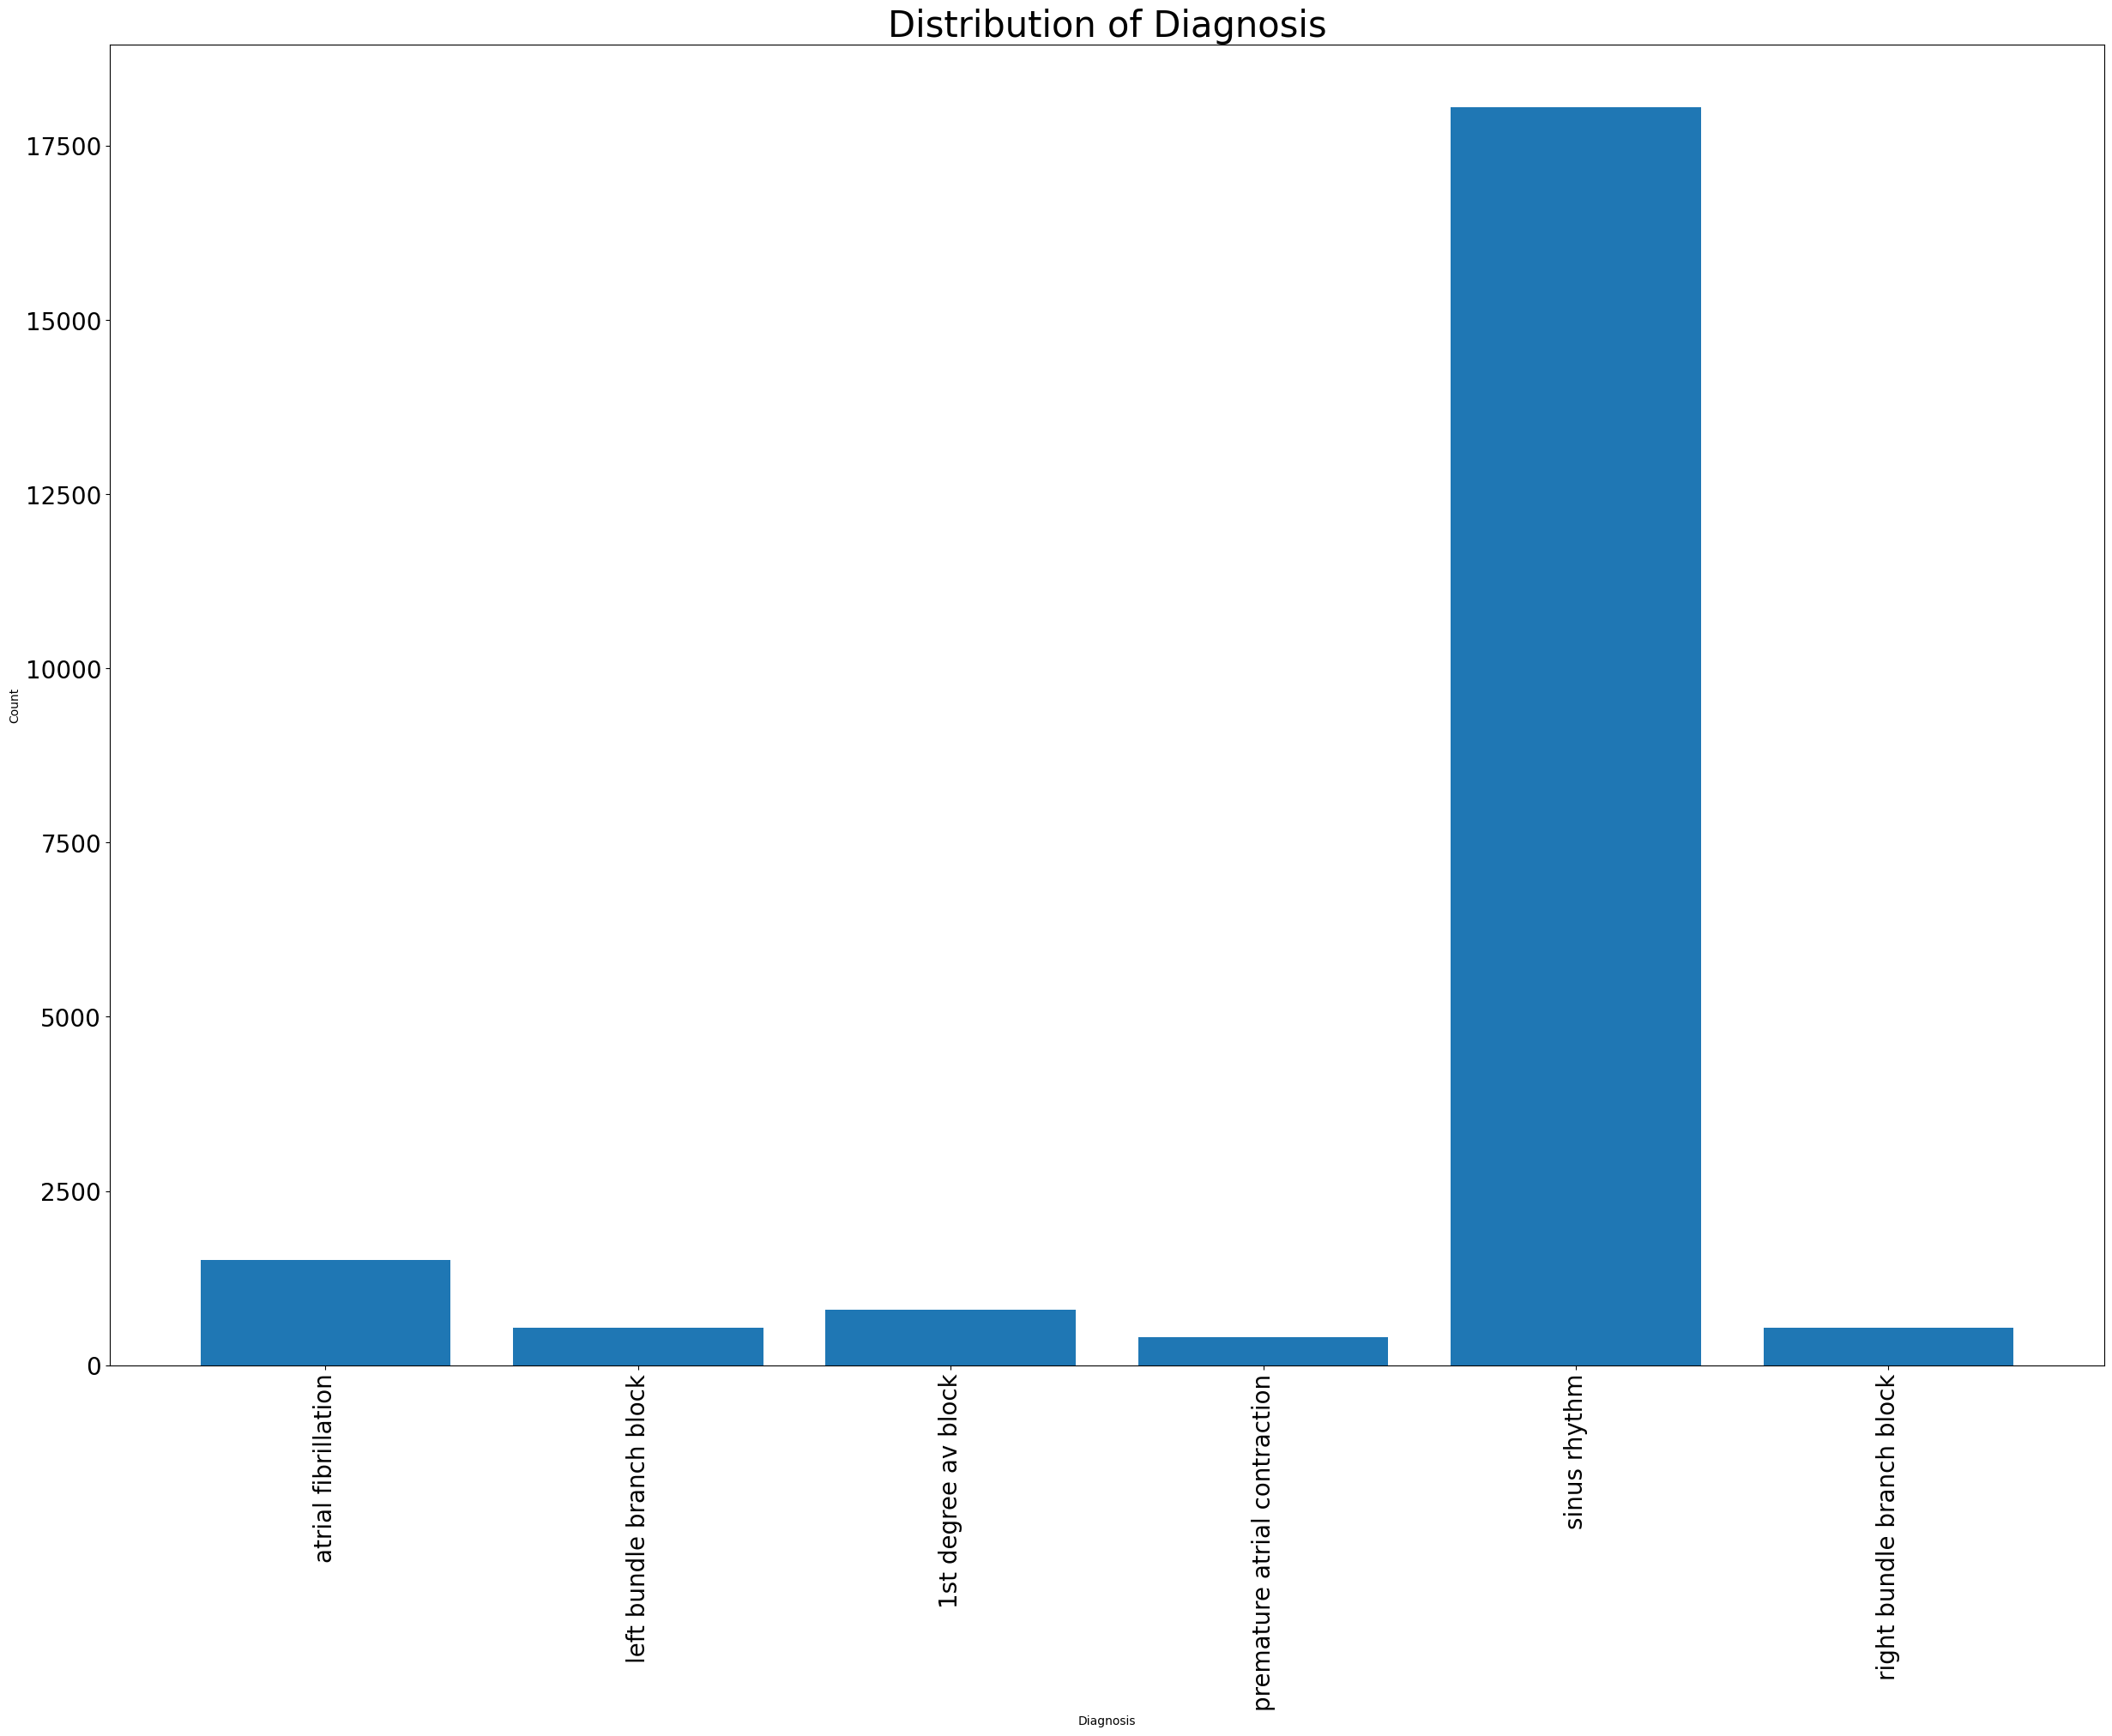

In [10]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

In [11]:
#Randomly oversample samples that ONLY involve minority classes
augmented_ecg_filenames = []
augmented_y = [] 
class_counts = np.sum(y, axis=0)
print(class_counts)
minor_classes = np.where(class_counts < np.max(class_counts))[0]  # Identify minor classes
majority_class = np.where(class_counts == np.max(class_counts))[0]
print(minor_classes,majority_class)

additional_samples = []
additional_labels = []

majority_class_indices = np.where((y[:, majority_class] == 1))[0]

for cls in minor_classes:
    # Find the indices of samples in the minor class
    minor_class_indices_included = np.where((y[:, cls] == 1))[0]
    # print(len(minor_class_indices_included), len(majority_class_indices))
    #all samples that only have minor classes 
    minor_class_indices_excluded = list(set(minor_class_indices_included) - set(majority_class_indices))
    # print(len(minor_class_indices_excluded))
    choices = np.asarray(minor_class_indices_excluded)
    for i in choices:
        if y[i][majority_class] == 1:
            print('error')
    # print(minor_class_indices)
    # Randomly oversample with replacement
    sampled_indices = np.random.choice(choices, class_counts[majority_class]-len(minor_class_indices_excluded) , replace=True)
    print('len:', len(sampled_indices))
    for indice in sampled_indices:
        additional_samples.append(os.path.join('data/\\', "{0:05d}.png".format(indice)))
    additional_labels.append(y[sampled_indices])

# Combine original training set with the additional samples
additional_labels = np.concatenate(additional_labels)

augmented_ecg_filenames = np.append(ecg_filenames, additional_samples)
augmented_y = np.concatenate((y, additional_labels))

print(np.shape(augmented_ecg_filenames))
print(np.shape(augmented_y))

[ 1513   536   794   397 18056   541]
[0 1 2 3 5] [4]
len: 16580
len: 17891
len: 17873
len: 18009
len: 17878
(110030,)
(110030, 6)


In [12]:
ecg_filenames = augmented_ecg_filenames
y = augmented_y

In [13]:
#Randomly remove samples to reduce dataset size
count = 0
pop_list = []
for i in range(len(ecg_filenames)):
    flag = np.random.rand()
    if flag>0.2:
        pop_list.append(i)
len(pop_list)        

88020

In [14]:
ecg_filenames = np.delete(ecg_filenames,pop_list)
y = np.delete(y,pop_list, axis = 0)

In [15]:
np.shape(y)

(22010, 6)

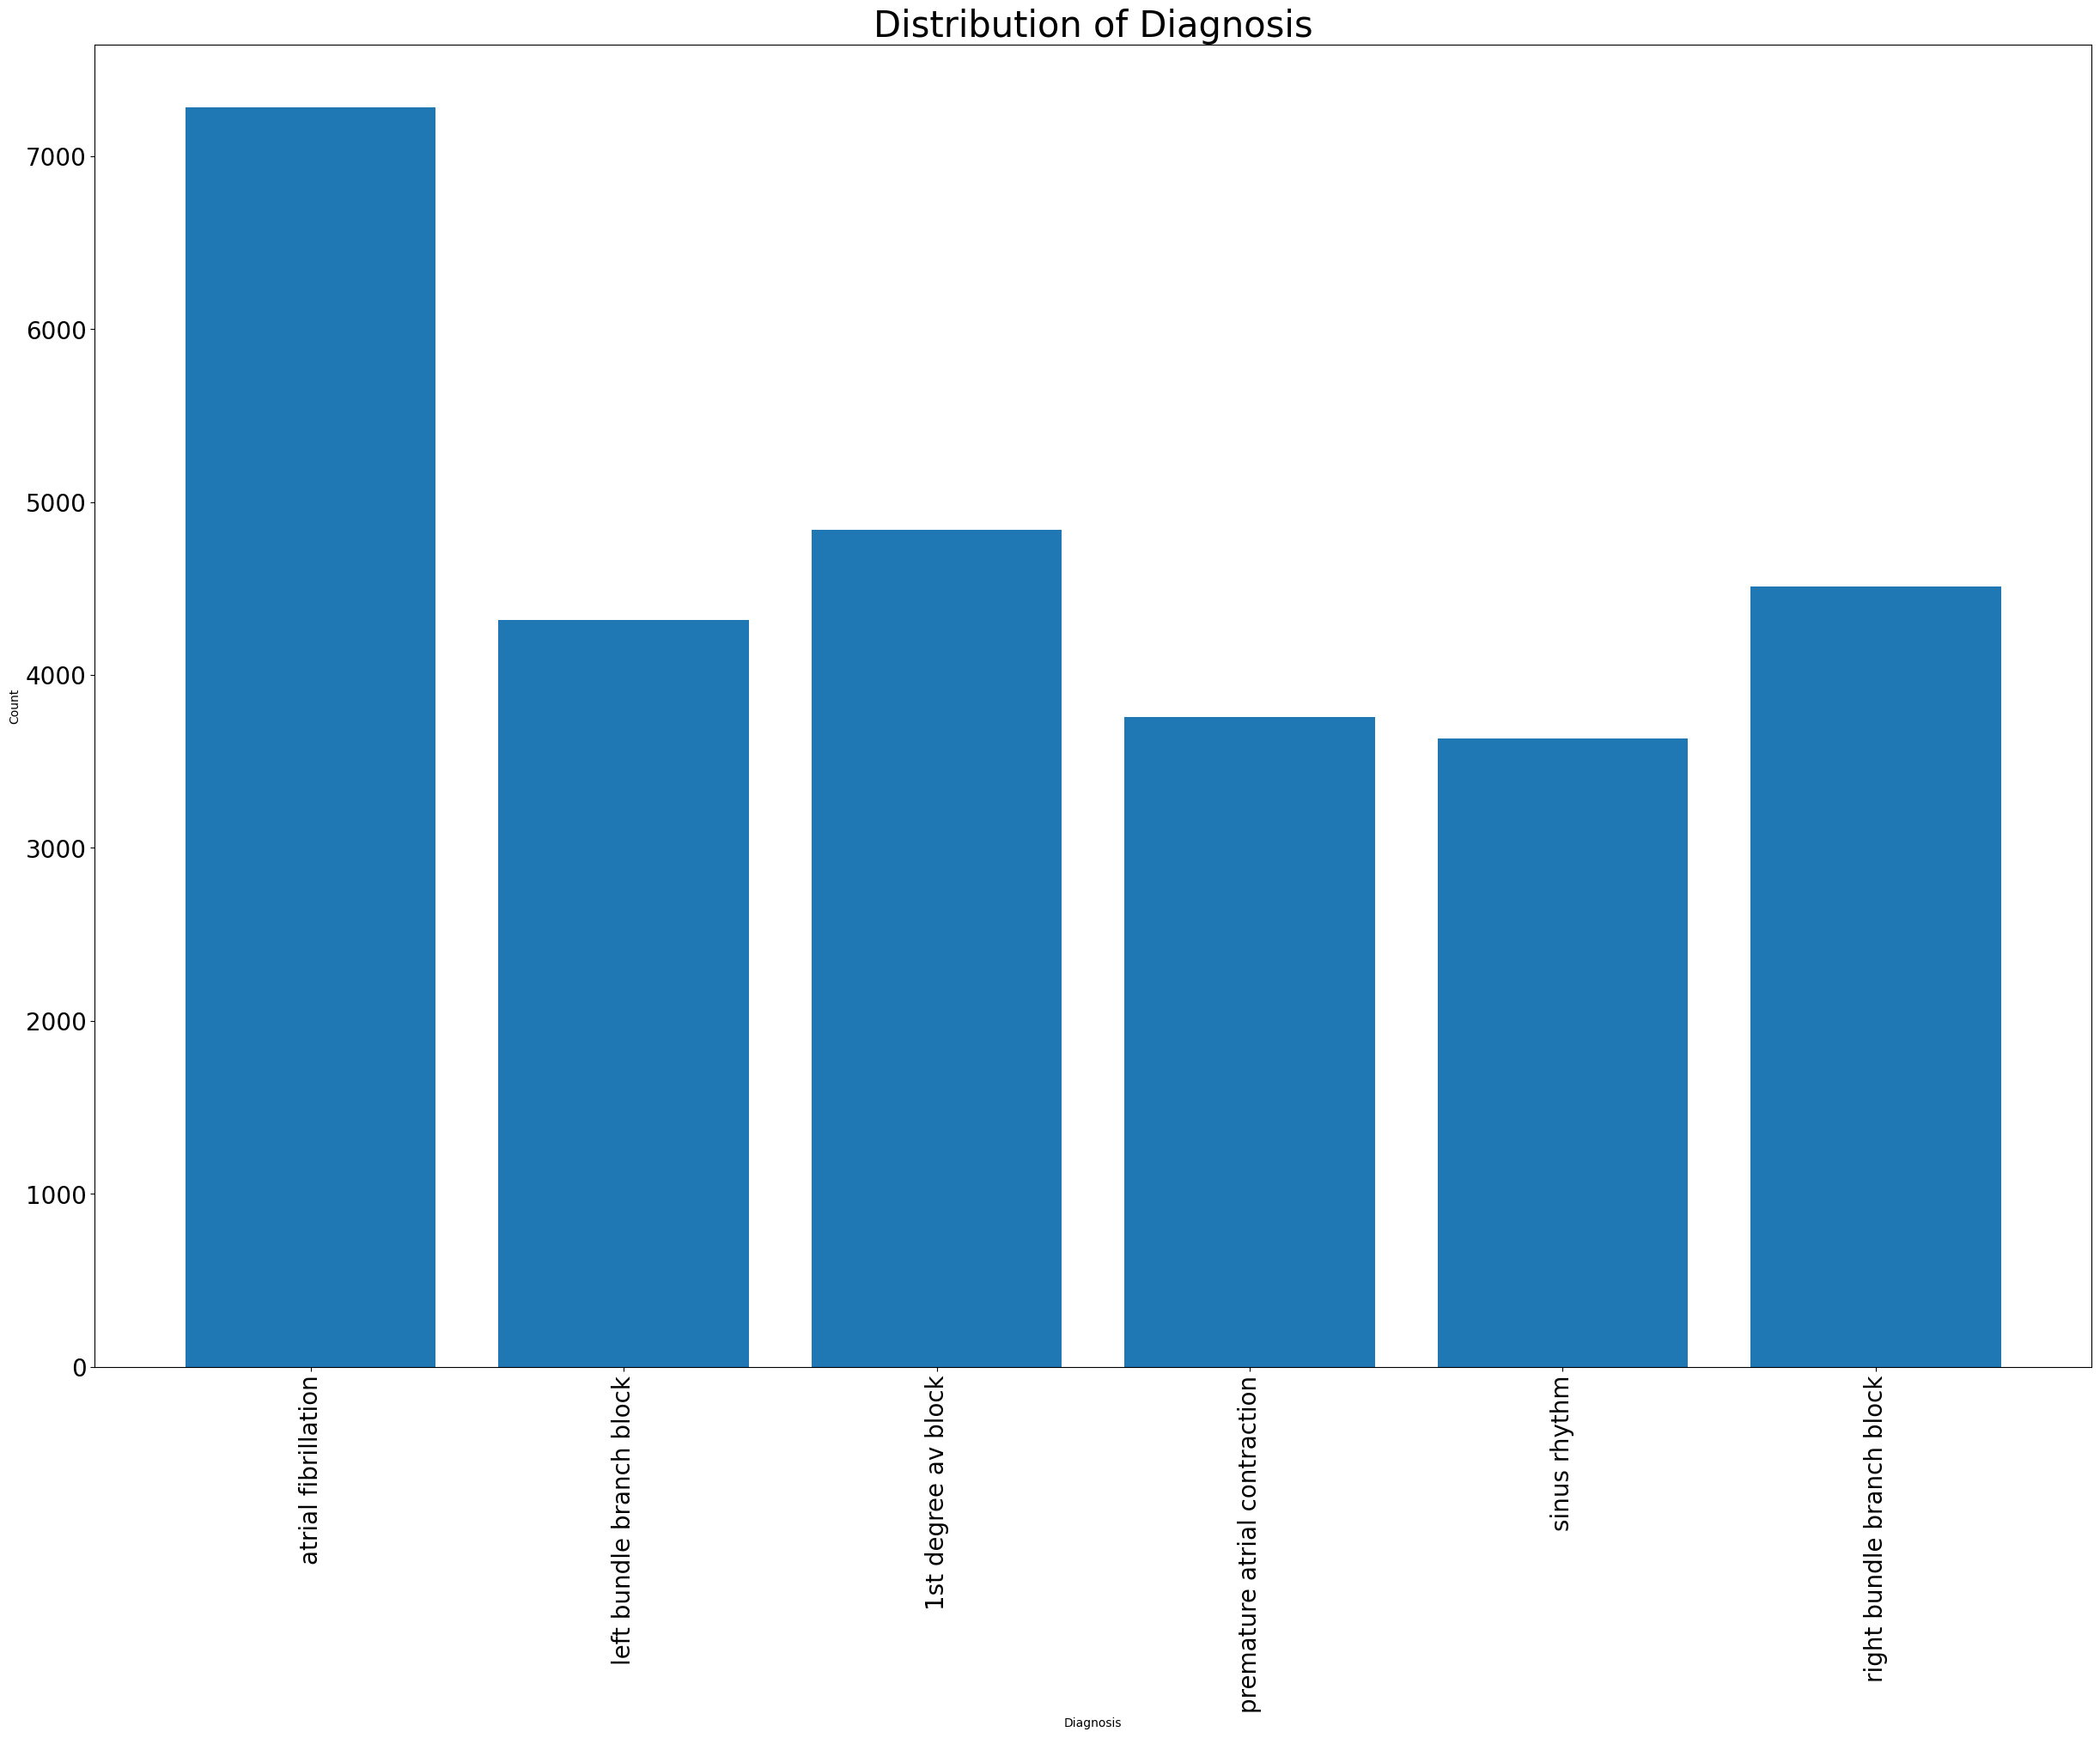

In [16]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader

class MultiLabelDataset(Dataset):
    def __init__(self, file_paths, labels, data_function, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.data_function = data_function

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Get file path and label for the current index
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load image data using data_function
        image = self.data_function(file_path)
        
        # Convert image and label to torch tensors
        #image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)  # Ensure label is numeric

        
        return image, label


In [21]:
# Example lists for file paths and labels
file_paths = ecg_filenames  # Replace with actual paths
labels = y  # Replace with actual labels

# Define a simple data function for testing
def data_function(file_path):
    data, label = pc.load_challenge_data(file_path)
    return data 

# Initialize dataset and verify loading
dataset = MultiLabelDataset(file_paths, labels, data_function=data_function)

    

In [22]:
# Create DataLoader
batch_size = 64
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# # Test DataLoader
for images, labels in data_loader:
    print(f"Batch image shape: {images.shape}, Batch label shape: {labels.shape}")
    break

Batch image shape: torch.Size([64, 3, 300, 300]), Batch label shape: torch.Size([64, 6])


In [23]:
import torch
import torch.nn as nn
from torchvision import models

# Load pre-trained ResNet-101 model
model = models.resnet101(pretrained=True)

# Modify the final layer for multilabel output
num_classes = len(labels[0])  # Assuming labels are one-hot encoded or binary vectors
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

C:\Users\GSBME\anaconda3\envs\expose\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\GSBME\anaconda3\envs\expose\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
# Define the loss function
criterion = nn.BCEWithLogitsLoss()


In [25]:
from tqdm import tqdm
from sklearn.model_selection import KFold
import torch

num_epochs = 2
num_folds = 3
patience = 1  # Number of epochs to wait for improvement in validation loss before stopping early
min_delta = 0.001  # Minimum change to qualify as an improvement

# Define KFold cross-validator
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Assuming `dataset` is your full dataset, replace `data_loader` with fold-specific DataLoaders
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"Fold {fold + 1}/{num_folds}")
    
    # Create train and validation subsets
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_idx)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_idx)
    
    # Data loaders for this fold
    train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    val_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=val_subsampler)
    
    # Optimizer for each fold
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5, min_lr=1e-6)

    # Early stopping parameters
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    
    # Training loop for the current fold
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        # Progress bar for each epoch
        progress_bar = tqdm(train_loader, desc=f"Fold {fold + 1} Epoch {epoch + 1}/{num_epochs}", unit="batch", leave=False)

        for i, (images, labels) in enumerate(progress_bar):
            images = images.to(device)
            labels = labels.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Compute loss
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Accumulate loss
            running_loss += loss.item()
            
            # Threshold outputs for binary predictions
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            
            # Calculate accuracy
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.numel()
            
            # Update progress bar with loss and accuracy
            progress_bar.set_postfix(loss=running_loss / (i + 1), accuracy=correct_predictions / total_samples)

        # Calculate average loss and accuracy for the epoch
        avg_loss = running_loss / len(train_loader)
        accuracy = correct_predictions / total_samples
        print(f"Fold [{fold + 1}/{num_folds}], Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
        
        # Validation after each fold
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_samples += labels.numel()

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_samples
        print(f"Fold [{fold + 1}/{num_folds}] Validation, Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.4f}")
        
        # Check for early stopping
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0  # Reset counter if improvement is found
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch + 1}/{num_epochs} due to no improvement in validation loss.")
                break

        # Step the scheduler based on validation loss
        scheduler.step(avg_val_loss)


Fold 1/3


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'resnetPTBXL_weights_new.pth')


In [ ]:
# Load pre-trained ResNet-101 model
ResNet101 = models.resnet101(pretrained=True)

# Change the fc layer
ResNet101.fc = nn.Linear(ResNet101.fc.in_features, 20)

# Load the pre-trained weights, skipping the last layer
model_dict = ResNet101.state_dict()

pretrained_dict = torch.load('resnetPTBXL_weights_new.pth')

# Filter out the final fc layer weights
pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and 'fc' not in k}

# Update the model's state dict with the filtered weights
model_dict.update(pretrained_dict)
ResNet101.load_state_dict(model_dict)

## ViT Approach

In [27]:
import torch
import torch.nn as nn
from torchvision import models

#torchvision version is 0.11.3, needs to be >=0.12
# Load pre-trained ViT-B/16 model
model = models.vision_transformer.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
model

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a